<a href="https://colab.research.google.com/github/JGuerrero08/Integraci-n-de-Datos-y-Prospectiva/blob/main/Parcial1_Integraci%C3%B3n_EPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Parcial 1 - EPS**

Este trabajo trata sobre una entidad de salud (EPS) que necesita cerrar su sede de Sabaneta para ser más eficiente. El objetivo principal es encontrar la mejor forma de reubicar a los pacientes con diabetes en otras sucursales. Para lograrlo, primero usamos la Teoría de la Credibilidad, que nos ayuda a ver qué tan parecidas son las otras sedes a la que va a cerrar. Después, comparamos dos formas de organizar a los pacientes: el método de Valor de Pertenencia y el de Aceptación y Rechazo. Al final, revisamos cómo cambian los promedios y la repartición de los datos en las nuevas sedes para asegurar que la integración se hizo correctamente.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
##Se crea una base de datos donde cada hoja del excel es una sede diferente, en este caso es la sucursal de BELLO
XDB = '/content/drive/MyDrive/Integración de Datos/Base de Datos/3. Parcial - medical_attention_data.xlsx'
datos = pd.read_excel(XDB)
datos.head(10)

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,BEL-0001,167,44,50,135,19.375,0.788,49,0,Bello
1,BEL-0002,60,54,12,602,43.115,1.640,37,1,Bello
2,BEL-0003,104,89,13,845,21.230,1.958,35,1,Bello
3,BEL-0004,72,61,12,145,49.781,1.643,25,1,Bello
4,BEL-0005,68,75,58,529,45.160,0.471,79,1,Bello
5,BEL-0006,184,70,41,256,45.977,1.871,22,0,Bello
6,BEL-0007,135,89,44,700,24.707,0.658,56,1,Bello
7,BEL-0008,179,113,9,247,17.449,0.327,40,1,Bello
8,BEL-0009,57,61,12,256,47.579,1.661,47,0,Bello
9,BEL-0010,139,98,21,87,29.262,0.750,55,1,Bello


In [3]:
## Esta base de datos, es sobre la sucursal de Medellin
XDB = '/content/drive/MyDrive/Integración de Datos/Base de Datos/3. Parcial - medical_attention_data.xlsx'
datos1 = pd.read_excel(XDB,sheet_name=1)
datos1.head(10)

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,MED-0001,14,40,69,58,605,35.901,0.986,56,1,Medellín
1,MED-0002,14,165,112,7,143,29.895,1.377,73,1,Medellín
2,MED-0003,1,150,50,52,132,43.766,1.866,57,0,Medellín
3,MED-0004,2,55,60,56,705,35.141,1.038,43,1,Medellín
4,MED-0005,4,58,43,32,790,20.618,0.681,51,1,Medellín
5,MED-0006,11,65,41,31,588,21.866,2.203,67,1,Medellín
6,MED-0007,11,191,94,55,768,28.684,1.006,23,0,Medellín
7,MED-0008,6,188,76,17,328,34.599,2.009,81,0,Medellín
8,MED-0009,0,61,90,35,171,49.877,1.121,55,1,Medellín
9,MED-0010,9,164,80,38,72,17.791,0.758,60,1,Medellín


In [4]:
## Esta base de datos es sobre la sede de Envigado
XDB = '/content/drive/MyDrive/Integración de Datos/Base de Datos/3. Parcial - medical_attention_data.xlsx'
datos2 = pd.read_excel(XDB,sheet_name=2)
datos2.head(10)

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,ENV-0001,164,81,56,46,26.921,1.984,81,1,Envigado
1,ENV-0002,121,71,15,245,29.110,2.484,22,1,Envigado
2,ENV-0003,187,46,9,609,32.877,2.142,27,0,Envigado
3,ENV-0004,82,81,6,564,49.109,1.293,29,1,Envigado
4,ENV-0005,88,64,51,409,31.105,2.213,40,1,Envigado
5,ENV-0006,121,43,32,229,28.763,0.385,27,1,Envigado
6,ENV-0007,152,119,55,542,20.052,0.580,55,0,Envigado
7,ENV-0008,67,105,17,763,33.969,1.399,81,0,Envigado
8,ENV-0009,92,117,8,265,39.155,1.880,61,1,Envigado
9,ENV-0010,87,64,49,278,30.239,0.809,51,0,Envigado


In [5]:
## Esta base de datos es sobrre la sede de Itagui
XDB = '/content/drive/MyDrive/Integración de Datos/Base de Datos/3. Parcial - medical_attention_data.xlsx'
datos3 = pd.read_excel(XDB,sheet_name=3)
datos3.head(10)

,PatientID,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,ITA-0001,89,39,736,25.563,0.557,59,0,Itagui
1,ITA-0002,99,31,238,49.786,1.190,46,0,Itagui
2,ITA-0003,110,18,593,49.004,1.117,76,0,Itagui
3,ITA-0004,70,47,71,47.335,0.159,23,1,Itagui
4,ITA-0005,40,50,369,34.553,1.018,33,0,Itagui
5,ITA-0006,118,12,730,33.849,0.130,54,1,Itagui
6,ITA-0007,117,2,748,28.181,0.848,45,0,Itagui
7,ITA-0008,120,2,688,39.515,1.995,75,1,Itagui
8,ITA-0009,107,49,729,22.048,1.607,62,1,Itagui
9,ITA-0010,103,13,340,29.793,1.679,75,1,Itagui


In [6]:
## Esta base de datos es sobre la sede de Sabaneta
XDB = '/content/drive/MyDrive/Integración de Datos/Base de Datos/3. Parcial - medical_attention_data.xlsx'
datos4 = pd.read_excel(XDB,sheet_name=4)
datos4.head(10)

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,SAB-0001,196,101,0,321,31.010,0.352,80,0,Sabaneta
1,SAB-0002,93,115,17,366,27.789,1.846,31,0,Sabaneta
2,SAB-0003,95,73,37,135,44.594,1.461,63,1,Sabaneta
3,SAB-0004,94,91,19,191,23.219,1.303,22,0,Sabaneta
4,SAB-0005,189,47,22,600,24.747,0.993,43,1,Sabaneta
5,SAB-0006,185,58,34,619,33.292,0.589,30,0,Sabaneta
6,SAB-0007,108,92,6,284,30.470,1.493,46,1,Sabaneta
7,SAB-0008,191,110,54,435,34.060,1.279,80,1,Sabaneta
8,SAB-0009,196,45,17,490,21.073,2.444,69,0,Sabaneta
9,SAB-0010,163,62,33,834,29.303,1.329,40,1,Sabaneta


In [7]:
## Esta es sobre la sede de Caldas
XDB = '/content/drive/MyDrive/Integración de Datos/Base de Datos/3. Parcial - medical_attention_data.xlsx'
datos5 = pd.read_excel(XDB,sheet_name=5)
datos5.head(10)

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,CAL-0001,166,41,40,31,29.526,1.293,63,0,Caldas
1,CAL-0002,162,55,32,134,15.300,2.205,72,0,Caldas
2,CAL-0003,185,79,29,188,33.307,0.113,24,0,Caldas
3,CAL-0004,74,117,25,553,38.052,1.040,71,1,Caldas
4,CAL-0005,183,95,44,196,29.501,1.694,71,0,Caldas
5,CAL-0006,53,48,16,112,31.665,0.465,54,1,Caldas
6,CAL-0007,196,49,13,335,27.748,0.656,61,1,Caldas
7,CAL-0008,177,54,52,520,36.313,0.852,81,0,Caldas
8,CAL-0009,162,120,23,413,18.959,0.535,77,1,Caldas
9,CAL-0010,124,98,33,363,24.597,0.492,31,1,Caldas


In [8]:
##Cómo se va a evaluar la crredibilidad y aceptación, necesitamos saber si hay algún dato faltante
datos4.isna().sum()

,0
PatientID,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Diabetes,0
Branch,0


In [ ]:
datos4.head(10)

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,SAB-0001,196,101,0,321,31.010,0.352,80,0,Sabaneta
1,SAB-0002,93,115,17,366,27.789,1.846,31,0,Sabaneta
2,SAB-0003,95,73,37,135,44.594,1.461,63,1,Sabaneta
3,SAB-0004,94,91,19,191,23.219,1.303,22,0,Sabaneta
4,SAB-0005,189,47,22,600,24.747,0.993,43,1,Sabaneta
5,SAB-0006,185,58,34,619,33.292,0.589,30,0,Sabaneta
6,SAB-0007,108,92,6,284,30.470,1.493,46,1,Sabaneta
7,SAB-0008,191,110,54,435,34.060,1.279,80,1,Sabaneta
8,SAB-0009,196,45,17,490,21.073,2.444,69,0,Sabaneta
9,SAB-0010,163,62,33,834,29.303,1.329,40,1,Sabaneta


In [9]:
datos_matrix =datos4

In [10]:
datos_matrix.insert(0, 'ID', np.arange(1, len(datos_matrix) + 1))

In [11]:
datos_matrix = datos4.drop('PatientID', axis=1)
datos_matrix.head()

,ID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,1,196,101,0,321,31.010,0.352,80,0,Sabaneta
1,2,93,115,17,366,27.789,1.846,31,0,Sabaneta
2,3,95,73,37,135,44.594,1.461,63,1,Sabaneta
3,4,94,91,19,191,23.219,1.303,22,0,Sabaneta
4,5,189,47,22,600,24.747,0.993,43,1,Sabaneta


In [12]:
datos_matrix = datos_matrix.drop('Branch', axis=1)
datos_matrix.head()

,ID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
0,1,196,101,0,321,31.010,0.352,80,0
1,2,93,115,17,366,27.789,1.846,31,0
2,3,95,73,37,135,44.594,1.461,63,1
3,4,94,91,19,191,23.219,1.303,22,0
4,5,189,47,22,600,24.747,0.993,43,1


In [13]:
corr_matrix = datos_matrix.corr()
corr_matrix

,ID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
ID,1.000000,-0.038399,-0.059369,-0.032741,-0.019341,-0.051557,-0.066363,-0.005972,0.009829
Glucose,-0.038399,1.000000,0.041401,-0.052986,0.011934,-0.013155,-0.049938,0.046391,0.015017
BloodPressure,-0.059369,0.041401,1.000000,0.050579,-0.062679,-0.015404,0.003125,0.028763,0.045078
SkinThickness,-0.032741,-0.052986,0.050579,1.000000,-0.010709,0.121183,0.047130,0.073044,0.063877
Insulin,-0.019341,0.011934,-0.062679,-0.010709,1.000000,-0.019577,0.003369,0.043300,0.053413
BMI,-0.051557,-0.013155,-0.015404,0.121183,-0.019577,1.000000,-0.014384,-0.043448,0.034468
DiabetesPedigreeFunction,-0.066363,-0.049938,0.003125,0.047130,0.003369,-0.014384,1.000000,-0.014101,0.026072
Age,-0.005972,0.046391,0.028763,0.073044,0.043300,-0.043448,-0.014101,1.000000,-0.026335
Diabetes,0.009829,0.015017,0.045078,0.063877,0.053413,0.034468,0.026072,-0.026335,1.000000


**Matriz de Corelación**

Al hacer la matriz, nos damos cuenta que no hay variables con una gran dependencia, sin embargo se puede observar algunas cosas de corelación, La Diabetes es una variable binaria, es decir 1 o 0, sin embargo tiene un poco de relación con variables cómo Presión de la sangre, BMI y Glucosa, por ende para poder sacar las variables a medir credibilidad y poder ver la afinidad, se pueden sacar varias de estas, teniendo presente la edad.
Al realizar la nueva variable, multipliqué 3 de ellas, pero me di cuenta que los número era muy elevados y me afectaban mucho los resultados, por ende tomé la desición de trabajar sólo con BMI, para que fuera más claro y más cercano, además la Glucosa es muy importante para trabajar, pero cómo una sucursal no la tiene encienta, no la trabaje.

In [ ]:
datos_matrix.head(10)

In [14]:
##Con este codigo conocemos los valores estadisticos por Sucursal, en este caso revisamos la de Sabaneta que es la que se va a cerrar
datos4.describe()

,ID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
count,621.000000,621.000000,621.000000,621.000000,621.000000,621.000000,621.000000,621.000000,621.000000
mean,311.000000,115.821256,80.228663,30.400966,422.504026,32.992060,1.314498,51.673108,0.510467
std,179.411538,45.654084,23.709517,17.861256,239.814940,9.894817,0.716244,17.429334,0.500293
min,1.000000,40.000000,40.000000,0.000000,0.000000,15.003000,0.073000,21.000000,0.000000
25%,156.000000,75.000000,59.000000,15.000000,212.000000,24.478000,0.633000,38.000000,0.000000
50%,311.000000,114.000000,80.000000,31.000000,424.000000,32.923000,1.334000,52.000000,1.000000
75%,466.000000,154.000000,101.000000,47.000000,614.000000,41.537000,1.968000,66.000000,1.000000
max,621.000000,200.000000,120.000000,60.000000,849.000000,49.944000,2.492000,81.000000,1.000000


In [ ]:
##Resultados estadisticos de Bello
datos.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
count,502.000000,502.000000,502.000000,502.000000,502.00000,502.000000,502.000000,502.000000
mean,119.175299,79.565737,31.049801,421.641434,32.99048,1.271197,52.207171,0.490040
std,47.474598,24.105032,17.746257,241.854460,9.88173,0.719036,18.140748,0.500399
min,41.000000,40.000000,0.000000,1.000000,15.00300,0.070000,21.000000,0.000000
25%,76.250000,59.000000,16.000000,212.000000,24.31550,0.642750,37.000000,0.000000
50%,122.000000,79.500000,32.000000,431.500000,33.45750,1.253000,53.000000,0.000000
75%,157.750000,101.000000,47.000000,628.000000,40.79875,1.886500,69.000000,1.000000
max,200.000000,120.000000,60.000000,850.000000,49.85300,2.496000,81.000000,1.000000


In [ ]:
##Resultados estadisticos de Medellín
datos1.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
count,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000,895.000000
mean,8.170950,122.277095,79.902793,30.345251,421.836872,32.879753,1.262841,51.626816,0.471508
std,5.079771,46.600008,23.171246,17.811288,251.093390,9.976137,0.700308,17.737439,0.499467
min,0.000000,40.000000,40.000000,0.000000,0.000000,15.008000,0.072000,21.000000,0.000000
25%,4.000000,82.000000,60.000000,15.000000,208.000000,24.114000,0.680500,36.000000,0.000000
50%,8.000000,125.000000,80.000000,31.000000,402.000000,33.085000,1.228000,52.000000,0.000000
75%,12.000000,163.000000,100.000000,46.000000,641.000000,41.213000,1.875000,67.000000,1.000000
max,17.000000,200.000000,120.000000,60.000000,849.000000,49.971000,2.498000,81.000000,1.000000


**Sacamos las variables para poder ver la afinidad**

1. De la base de Datos de sabaneta, necesitamos, Edad, Presión de la Sangre, BMI.

In [ ]:
datos2.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes
count,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.00000,792.000000
mean,120.330808,77.619949,30.003788,432.608586,32.550485,1.293193,50.77904,0.486111
std,45.197940,23.359679,17.642932,246.577064,9.827211,0.685173,17.46285,0.500123
min,40.000000,40.000000,0.000000,0.000000,15.096000,0.070000,21.00000,0.000000
25%,79.750000,57.000000,15.000000,229.000000,24.387000,0.700500,36.00000,0.000000
50%,120.000000,76.000000,30.000000,430.000000,32.983500,1.291000,50.00000,0.000000
75%,159.000000,98.000000,45.000000,643.000000,40.398750,1.882000,66.00000,1.000000
max,200.000000,120.000000,60.000000,850.000000,49.993000,2.499000,81.00000,1.000000


In [ ]:
datos4.head(10)

,ID,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,1,SAB-0001,196,101,0,321,31.010,0.352,80,0,Sabaneta
1,2,SAB-0002,93,115,17,366,27.789,1.846,31,0,Sabaneta
2,3,SAB-0003,95,73,37,135,44.594,1.461,63,1,Sabaneta
3,4,SAB-0004,94,91,19,191,23.219,1.303,22,0,Sabaneta
4,5,SAB-0005,189,47,22,600,24.747,0.993,43,1,Sabaneta
5,6,SAB-0006,185,58,34,619,33.292,0.589,30,0,Sabaneta
6,7,SAB-0007,108,92,6,284,30.470,1.493,46,1,Sabaneta
7,8,SAB-0008,191,110,54,435,34.060,1.279,80,1,Sabaneta
8,9,SAB-0009,196,45,17,490,21.073,2.444,69,0,Sabaneta
9,10,SAB-0010,163,62,33,834,29.303,1.329,40,1,Sabaneta


In [23]:
##Esta serán las variables que sacamos de la sucursal Sabaneta, se van a diferenciar por el numero de hoja del excel
BMI=datos4.iloc[:,6]



In [24]:
##Estos seran los número de Bello, por ser la hoja 1

BMI1=datos.iloc[:,5]

In [25]:
BMI2= datos1.iloc[:,6]

In [26]:
BMI3 = datos2.iloc[:,5]

In [27]:
##Datos prom para Itaguí
BMI4=datos3.iloc[:,4]


In [28]:
##Datos prom para Caldas

BMI5=datos5.iloc[:,5]


In [ ]:
datos5.head(10)

,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,CAL-0001,166,41,40,31,29.526,1.293,63,0,Caldas
1,CAL-0002,162,55,32,134,15.300,2.205,72,0,Caldas
2,CAL-0003,185,79,29,188,33.307,0.113,24,0,Caldas
3,CAL-0004,74,117,25,553,38.052,1.040,71,1,Caldas
4,CAL-0005,183,95,44,196,29.501,1.694,71,0,Caldas
5,CAL-0006,53,48,16,112,31.665,0.465,54,1,Caldas
6,CAL-0007,196,49,13,335,27.748,0.656,61,1,Caldas
7,CAL-0008,177,54,52,520,36.313,0.852,81,0,Caldas
8,CAL-0009,162,120,23,413,18.959,0.535,77,1,Caldas
9,CAL-0010,124,98,33,363,24.597,0.492,31,1,Caldas


In [ ]:
datos1.head(10)

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,MED-0001,14,40,69,58,605,35.901,0.986,56,1,Medellín
1,MED-0002,14,165,112,7,143,29.895,1.377,73,1,Medellín
2,MED-0003,1,150,50,52,132,43.766,1.866,57,0,Medellín
3,MED-0004,2,55,60,56,705,35.141,1.038,43,1,Medellín
4,MED-0005,4,58,43,32,790,20.618,0.681,51,1,Medellín
5,MED-0006,11,65,41,31,588,21.866,2.203,67,1,Medellín
6,MED-0007,11,191,94,55,768,28.684,1.006,23,0,Medellín
7,MED-0008,6,188,76,17,328,34.599,2.009,81,0,Medellín
8,MED-0009,0,61,90,35,171,49.877,1.121,55,1,Medellín
9,MED-0010,9,164,80,38,72,17.791,0.758,60,1,Medellín


In [29]:
def caracterizacion(BMI):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(BMI,bins=10,kde=True)
  plt.xlabel("Salud, varias variables")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(BMI,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df

In [30]:
def RiskParameters(prom4):

  NDT=len(BMI)
  PE=np.mean(BMI)                        #Pérdidas Esperadas
  NPE=np.sum(BMI<PE)                     #Cuantos eventos de riesgo no generan cobro - Evergreen
  OpVar=np.percentile(BMI1,99.9)         #Valor Seguro para cubrir pérdidas catastróficas que requieren intervención de seguro
  NPC=np.sum(BMI>OpVar)                  #Pérdidas Catastróficas
  NPNE=NDT-NPE-NPC                       #Las pérdidas no esperadas - gestionables (llevo el carro al taller)

  return OpVar,NPE,NPNE,NPC

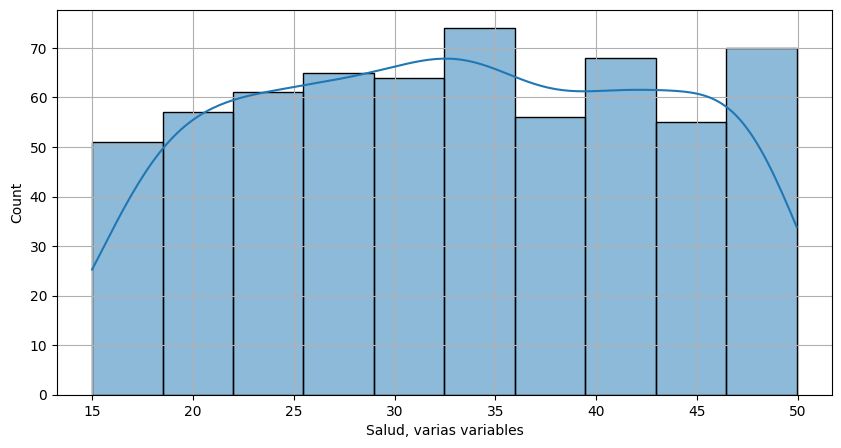

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]
La media de los datos observados es: 32.96582487922706
El coeficiente de asimetría es:  -0.025742157381107963


In [31]:
uo,sigmao, Caso, Kuo,dfo=caracterizacion(BMI)
print("La media de los datos observados es:", uo)
print("El coeficiente de asimetría es: ", Caso)

Medidas de tendencia
2. Vamos a evaluar cada medida por base de datos, para ver más o menos cómo estan de similares los datos


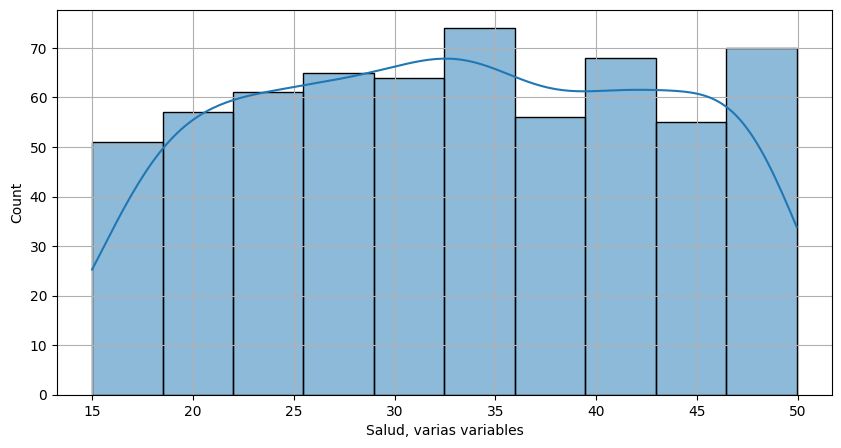

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]
La media de los datos observados es en Sabaneta: 32.96582487922706
El coeficiente de asimetría es en Sabaneta:  -0.025742157381107963


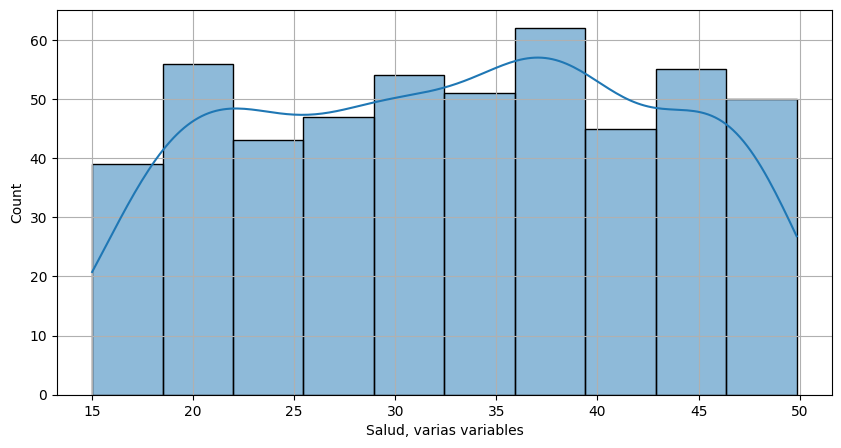

El número de datos por intervalo es:
[39 56 43 47 54 51 62 45 55 50]
Los intervalos inferiores:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]
La media de los datos observados es en Bello: 32.9278406374502
El coeficiente de asimetría es en Bello:  -0.0599453089846441


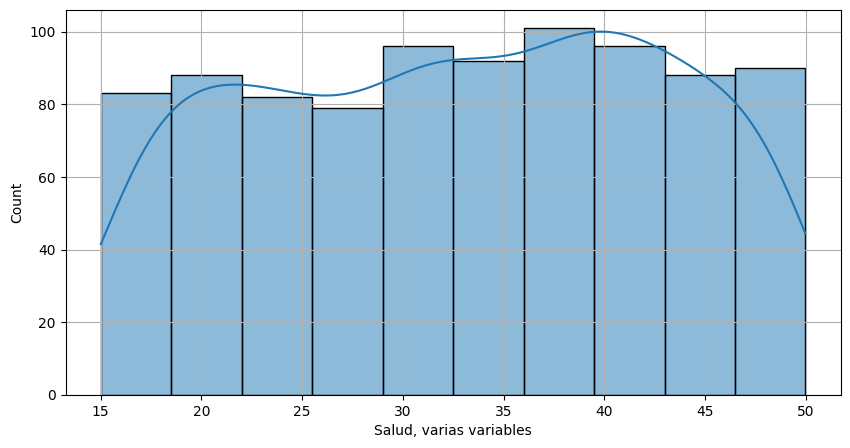

El número de datos por intervalo es:
[ 83  88  82  79  96  92 101  96  88  90]
Los intervalos inferiores:
[15.008  18.5043 22.0006 25.4969 28.9932 32.4895 35.9858 39.4821 42.9784
 46.4747]
Los intervalos superiores:
[18.5043 22.0006 25.4969 28.9932 32.4895 35.9858 39.4821 42.9784 46.4747
 49.971 ]
La media de los datos observados es en Medellín: 32.870381843575416
El coeficiente de asimetría es en Medellín:  -0.06974264498227505


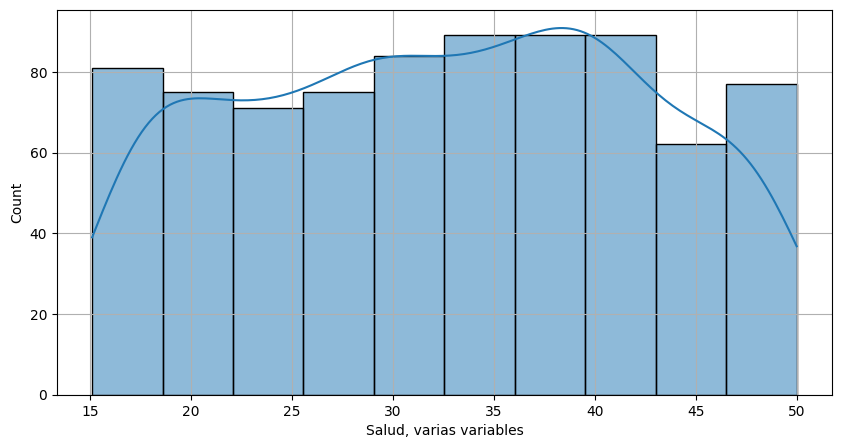

El número de datos por intervalo es:
[81 75 71 75 84 89 89 89 62 77]
Los intervalos inferiores:
[15.096  18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136
 46.5033]
Los intervalos superiores:
[18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136 46.5033
 49.993 ]
La media de los datos observados es en Envigado: 32.56653093434344
El coeficiente de asimetría es en Envigado:  -0.040160184651065974


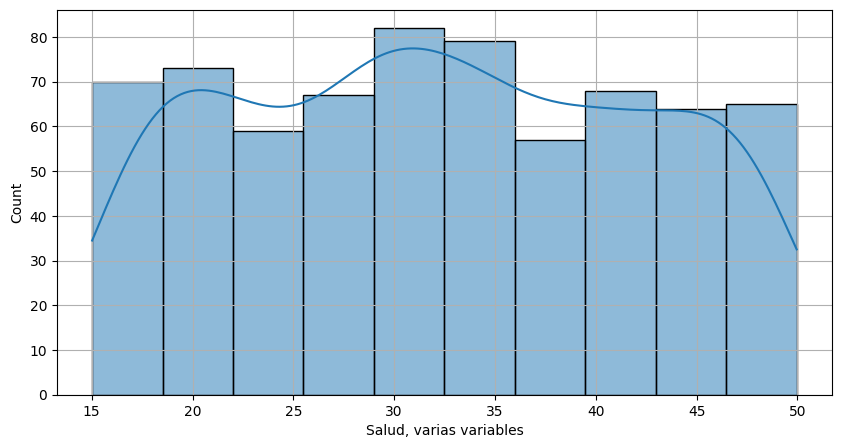

El número de datos por intervalo es:
[70 73 59 67 82 79 57 68 64 65]
Los intervalos inferiores:
[15.019  18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758
 46.4704]
Los intervalos superiores:
[18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758 46.4704
 49.965 ]
La media de los datos observados es en Itaguí: 32.2467649122807
El coeficiente de asimetría es en Itaguí:  0.027261582779057495


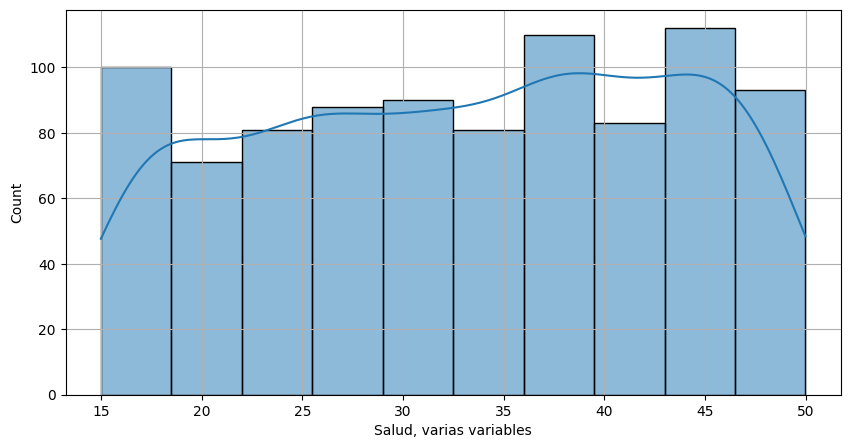

El número de datos por intervalo es:
[100  71  81  88  90  81 110  83 112  93]
Los intervalos inferiores:
[15.     18.4985 21.997  25.4955 28.994  32.4925 35.991  39.4895 42.988
 46.4865]
Los intervalos superiores:
[18.4985 21.997  25.4955 28.994  32.4925 35.991  39.4895 42.988  46.4865
 49.985 ]
La media de los datos observados es en Caldas: 33.05249092409241
El coeficiente de asimetría es en Caldas:  -0.11052613512445673


In [32]:
#Base de datos Sabaneta
us,sigmas, Cass, Kus,dfs=caracterizacion(BMI)
print("La media de los datos observados es en Sabaneta:", us)
print("El coeficiente de asimetría es en Sabaneta: ", Cass)
OpVars,NPEs,NPNEs,NPCs=RiskParameters(BMI)

#Base de datos de Bello
ub,sigmab, Casb, Kub,dfb=caracterizacion(BMI1)
print("La media de los datos observados es en Bello:", ub)
print("El coeficiente de asimetría es en Bello: ", Casb)
OpVarb,NPEb,NPNEb,NPCb=RiskParameters(BMI1)

#Base de datos de Medellín
um,sigmam, Casm, Kum,dfm=caracterizacion(BMI2)
print("La media de los datos observados es en Medellín:", um)
print("El coeficiente de asimetría es en Medellín: ", Casm)
OpVarm,NPEm,NPNEm,NPCm=RiskParameters(BMI2)

#Base de datos Envigado
ue,sigmae, Case, Kue,dfe=caracterizacion(BMI3)
print("La media de los datos observados es en Envigado:", ue)
print("El coeficiente de asimetría es en Envigado: ", Case)
OpVare,NPEe,NPNEe,NPCe=RiskParameters(BMI3)

#Base de datos Itaguí
ui,sigmai, Casi, Kui,dfi=caracterizacion(BMI4)
print("La media de los datos observados es en Itaguí:", ui)
print("El coeficiente de asimetría es en Itaguí: ", Casi)
OpVari,NPEi,NPNEi,NPCi=RiskParameters(BMI4)

#Base de datos en Caldas
uc,sigmac, Casc, Kuc,dfc=caracterizacion(BMI5)
print("La media de los datos observados es en Caldas:", uc)
print("El coeficiente de asimetría es en Caldas: ", Casc)
OpVarc,NPEc,NPNEc,NPCc=RiskParameters(BMI5)

#**Analisis de las medidas de tendencia**

1. Todas las sedes tienen una media de los datos muy similares, están al rededor de 32 a 33, mientras que el coeficiente de asimetría de las sucursales estan al rededor de -0.04 a 0.02, en este caso la de 0.02 es Itaguí, que precisamente es la sucursal que tiene más afinidad con Sabaneta.

In [33]:
BMI.describe()

,BMI
count,621.000000
mean,32.992060
std,9.894817
min,15.003000
25%,24.478000
50%,32.923000
75%,41.537000
max,49.944000


In [34]:
BMI1.describe()

,BMI
count,502.00000
mean,32.99048
std,9.88173
min,15.00300
25%,24.31550
50%,33.45750
75%,40.79875
max,49.85300


##**Se evalúa Credibilidad**

Empezamos evaluando la credibilidad de Sabaneta con Bello

In [35]:
#Se procede del valor esperado de la varianza
NDs=len(BMI);NDb=len(BMI1)
EPV=(sigmas*NDs+sigmab*NDb)/(NDs+NDb)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(us*NDs+ub*NDb)/(NDs+NDb)
VHM=((NDs*us**2+NDb*ub**2)/(NDs+NDb))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr=NDs/(NDs+fc)
print("La media de los datos internos es:",us)
print("La media de los datos externos es:",ub)
print("La credibilidad es:",Cr)

La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La credibilidad es: 0.022050146729361828


In [36]:
##Se evalúa la credibilidad de Sabaneta con Medellín
#Se procede del valor esperado de la varianza
NDs=len(BMI);NDm=len(BMI1)
EPV=(sigmas*NDs+sigmam*NDm)/(NDs+NDm)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(us*NDs+um*NDm)/(NDs+NDm)
VHM=((NDs*us**2+NDm*um**2)/(NDs+NDm))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr=NDs/(NDs+fc)
print("La media de los datos internos es:",us)
print("La media de los datos externos es:",um)
print("La credibilidad es:",Cr)

La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.870381843575416
La credibilidad es: 0.12401713403873575


In [37]:
##Se evalúa la credibilidad de Sabaneta con Envigado
#Se procede del valor esperado de la varianza
NDs=len(BMI);NDe=len(BMI2)
EPV=(sigmas*NDs+sigmae*NDe)/(NDs+NDe)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(us*NDs+ue*NDe)/(NDs+NDe)
VHM=((NDs*us**2+NDe*ue**2)/(NDs+NDe))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr=NDs/(NDs+fc)
print("La media de los datos internos es:",us)
print("La media de los datos externos es:",ue)
print("La credibilidad es:",Cr)

La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.56653093434344
La credibilidad es: 0.7088234070788628


In [38]:
##Se evalúa la credibilidad de Sabaneta con Itaguí
#Se procede del valor esperado de la varianza
NDs=len(BMI);NDi=len(BMI3)
EPV=(sigmas*NDs+sigmae*NDi)/(NDs+NDi)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(us*NDs+ui*NDi)/(NDs+NDi)
VHM=((NDs*us**2+NDi*ui**2)/(NDs+NDi))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr=NDs/(NDs+fc)
print("La media de los datos internos es:",us)
print("La media de los datos externos es:",ui)
print("La credibilidad es:",Cr)

La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.2467649122807
La credibilidad es: 0.8893991107327959


In [39]:
##Se evalúa la credibilidad de Sabaneta con Cladas
#Se procede del valor esperado de la varianza
NDs=len(BMI);NDc=len(BMI5)
EPV=(sigmas*NDs+sigmac*NDc)/(NDs+NDc)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(us*NDs+uc*NDc)/(NDs+NDc)
VHM=((NDs*us**2+NDc*uc**2)/(NDs+NDc))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr=NDs/(NDs+fc)
print("La media de los datos internos es:",us)
print("La media de los datos externos es:",uc)
print("La credibilidad es:",Cr)

La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 33.05249092409241
La credibilidad es: 0.10093355882909404


#**Análisis de las credibilidades**

La credibilidad entre todas las sedes con Sabaneta, podemos evidenciar que la sede con una credibilidad mayor es Itaguí, con un porcentaje de 88%, mientras que otras sedes cómo son Bello o Caldas no pasan del 10%, esto sumado que la discrepancia de las medias esta entre 7% y 10% que corrobora la credibilidad.


Datos de Integración

#**Integración Sabaneta con Bello**


In [40]:
BMIint=np.copy(np.array(BMI))   #Variable de Integración
BMI1=np.array(BMI1)

m1=0
for k in range(len(BMI1)):
  VP=np.exp(-0.5*((us-BMI1[k,])/sigmas)**2)

  if VP>0.9:
      m1=m1+1   #Contador de cuantos datos integrados
      BMIint=np.append(BMIint,BMI1[k])
      print("El dato a integrar es:",BMI1[k])

print("Los datos integrados son:",m1)

El dato a integrar es: 29.262
El dato a integrar es: 34.485
El dato a integrar es: 32.358
El dato a integrar es: 36.285
El dato a integrar es: 32.157
El dato a integrar es: 31.307
El dato a integrar es: 31.328
El dato a integrar es: 33.093
El dato a integrar es: 31.204
El dato a integrar es: 33.303
El dato a integrar es: 36.183
El dato a integrar es: 33.482
El dato a integrar es: 29.866
El dato a integrar es: 35.845
El dato a integrar es: 29.671
El dato a integrar es: 33.316
El dato a integrar es: 31.983
El dato a integrar es: 31.588
El dato a integrar es: 36.938
El dato a integrar es: 29.17
El dato a integrar es: 34.997
El dato a integrar es: 34.003
El dato a integrar es: 28.937
El dato a integrar es: 37.304
El dato a integrar es: 29.12
El dato a integrar es: 33.207
El dato a integrar es: 33.236
El dato a integrar es: 28.756
El dato a integrar es: 30.372
El dato a integrar es: 29.658
El dato a integrar es: 30.619
El dato a integrar es: 29.378
El dato a integrar es: 34.998
El dato a in

19.375
43.115
El dato integrado es 1
21.23
49.781
El dato integrado es 3
45.16
El dato integrado es 4
45.977
El dato integrado es 5
24.707
17.449
47.579
El dato integrado es 8
29.262
46.815
El dato integrado es 10
27.455
34.485
El dato integrado es 12
40.421
El dato integrado es 13
45.172
El dato integrado es 14
39.682
El dato integrado es 15
32.358
36.285
El dato integrado es 17
32.157
27.207
31.307
15.325
43.752
El dato integrado es 22
31.328
37.96
El dato integrado es 24
25.474
16.075
15.003
46.328
El dato integrado es 28
49.559
El dato integrado es 29
21.575
18.273
17.414
39.468
El dato integrado es 33
33.093
El dato integrado es 34
44.84
El dato integrado es 35
43.821
El dato integrado es 36
31.204
33.303
El dato integrado es 38
36.183
El dato integrado es 39
17.907
21.486
39.421
El dato integrado es 42
20.565
39.412
El dato integrado es 44
33.482
El dato integrado es 45
29.866
46.576
El dato integrado es 47
18.42
27.678
40.675
El dato integrado es 50
35.845
El dato integrado es 5

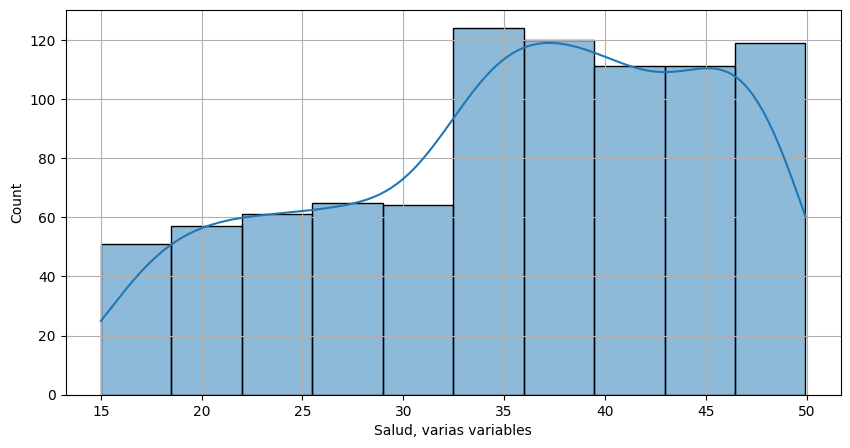

El número de datos por intervalo es:
[ 51  57  61  65  64 124 120 111 111 119]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]
La media de los datos integrados es: 35.37205973952435
La media de los datos observados es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La discrepancia entre las medias es: 7.2991798904251


In [41]:
##Método aceptación y rechazo entre Sabaneta y Bello

BMIint2=np.copy(np.array(BMI))

for k in range(len(BMI1)):
  print(BMI1[k])

  VPo = np.exp(-0.5*((us-BMI1[k])/sigmas)**2) #Que tanto se parece el dato de los internos
  VPe= np.exp(-0.5*((ue-BMI1[k])/sigmas)**2) #Que tan represnetativo es un dato externo

  if VPo>VPe:
    BMIint2=np.append(BMIint2,BMI1[k])
    print(f"El dato integrado es {k}")

ui2,sigmai2,Casi2,Kuri2,dfi2=caracterizacion(BMIint2)
print("La media de los datos integrados es:",ui2)
print("La media de los datos observados es:",us)
print("La media de los datos externos es:",ub)

duoui2=np.abs((us-ui2)/us)*100  #Discrepacia delos datos observados y los integrados
print("La discrepancia entre las medias es:",duoui2)

#**Integración Sabaneta con Medellín**

In [42]:
BMIint=np.copy(np.array(BMI))   #Variable de Integración
BMI2=np.array(BMI2)

m1=0
for k in range(len(BMI2)):
  VP=np.exp(-0.5*((us-BMI2[k,])/sigmas)**2)

  if VP>0.9:
      m1=m1+1   #Contador de cuantos datos integrados
      BMIint=np.append(BMIint,BMI2[k])
      print("El dato a integrar es:",BMI2[k])

print("Los datos integrados son:",m1)

El dato a integrar es: 35.901
El dato a integrar es: 29.895
El dato a integrar es: 35.141
El dato a integrar es: 28.684
El dato a integrar es: 34.599
El dato a integrar es: 31.521
El dato a integrar es: 37.036
El dato a integrar es: 29.688
El dato a integrar es: 31.408
El dato a integrar es: 30.679
El dato a integrar es: 32.261
El dato a integrar es: 28.98
El dato a integrar es: 33.687
El dato a integrar es: 35.808
El dato a integrar es: 31.578
El dato a integrar es: 35.032
El dato a integrar es: 30.188
El dato a integrar es: 28.824
El dato a integrar es: 32.838
El dato a integrar es: 32.938
El dato a integrar es: 30.664
El dato a integrar es: 33.705
El dato a integrar es: 29.771
El dato a integrar es: 36.052
El dato a integrar es: 31.169
El dato a integrar es: 34.954
El dato a integrar es: 29.919
El dato a integrar es: 37.307
El dato a integrar es: 33.405
El dato a integrar es: 36.633
El dato a integrar es: 35.156
El dato a integrar es: 34.256
El dato a integrar es: 33.482
El dato a i

35.901
El dato integrado es 0
29.895
43.766
El dato integrado es 2
35.141
El dato integrado es 3
20.618
21.866
28.684
34.599
El dato integrado es 7
49.877
El dato integrado es 8
17.791
31.521
18.178
16.3
25.26
48.797
El dato integrado es 14
23.55
47.341
El dato integrado es 16
49.964
El dato integrado es 17
23.7
20.209
48.098
El dato integrado es 20
18.458
41.181
El dato integrado es 22
40.416
El dato integrado es 23
26.731
18.18
24.45
40.586
El dato integrado es 27
41.234
El dato integrado es 28
37.036
El dato integrado es 29
29.688
22.425
43.341
El dato integrado es 32
31.408
30.679
49.834
El dato integrado es 35
22.867
22.229
47.752
El dato integrado es 38
32.261
16.99
48.502
El dato integrado es 41
40.532
El dato integrado es 42
28.98
37.914
El dato integrado es 44
15.223
33.687
El dato integrado es 46
27.013
38.795
El dato integrado es 48
19.093
24.708
40.604
El dato integrado es 51
48.571
El dato integrado es 52
35.808
El dato integrado es 53
47.199
El dato integrado es 54
20.66


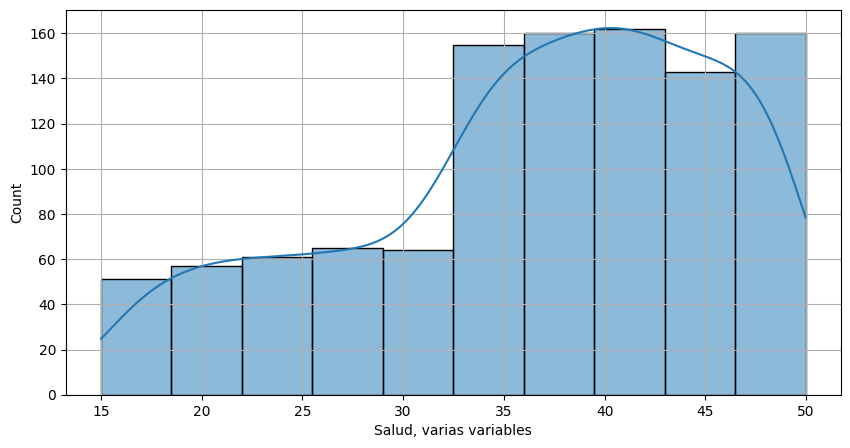

El número de datos por intervalo es:
[ 51  57  61  65  64 155 160 162 143 160]
Los intervalos inferiores:
[15.003  18.4998 21.9966 25.4934 28.9902 32.487  35.9838 39.4806 42.9774
 46.4742]
Los intervalos superiores:
[18.4998 21.9966 25.4934 28.9902 32.487  35.9838 39.4806 42.9774 46.4742
 49.971 ]
La media de los datos integrados es: 36.48334285714286
La media de los datos observados es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La discrepancia entre las medias es: 10.670195545849408


In [43]:
##Método aceptación y rechazo entre Sabaneta y Medellín

BMIint2=np.copy(np.array(BMI))

for k in range(len(BMI2)):
  print(BMI2[k])

  VPo = np.exp(-0.5*((us-BMI2[k])/sigmas)**2) #Que tanto se parece el dato de los internos
  VPe= np.exp(-0.5*((ue-BMI2[k])/sigmas)**2) #Que tan represnetativo es un dato externo

  if VPo>VPe:
    BMIint2=np.append(BMIint2,BMI2[k])
    print(f"El dato integrado es {k}")

ui2,sigmai2,Casi2,Kuri2,dfi2=caracterizacion(BMIint2)
print("La media de los datos integrados es:",ui2)
print("La media de los datos observados es:",us)
print("La media de los datos externos es:",ub)

duoui2=np.abs((us-ui2)/us)*100  #Discrepacia delos datos observados y los integrados
print("La discrepancia entre las medias es:",duoui2)

#**Integración de datos Sabaneta con Envigado**

In [45]:
BMIint=np.copy(np.array(BMI))   #Variable de Integración
BMI3=np.array(BMI3)

m1=0
for k in range(len(BMI3)):
  VP=np.exp(-0.5*((us-BMI3[k,])/sigmas)**2)

  if VP>0.9:
      m1=m1+1   #Contador de cuantos datos integrados
      BMIint=np.append(BMIint,BMI3[k])
      print("El dato a integrar es:",BMI3[k])

print("Los datos integrados son:",m1)

El dato a integrar es: 29.11
El dato a integrar es: 32.877
El dato a integrar es: 31.105
El dato a integrar es: 28.763
El dato a integrar es: 33.969
El dato a integrar es: 30.239
El dato a integrar es: 35.138
El dato a integrar es: 32.412
El dato a integrar es: 32.57
El dato a integrar es: 29.314
El dato a integrar es: 31.211
El dato a integrar es: 30.065
El dato a integrar es: 30.342
El dato a integrar es: 29.469
El dato a integrar es: 30.707
El dato a integrar es: 33.059
El dato a integrar es: 30.501
El dato a integrar es: 37.054
El dato a integrar es: 28.752
El dato a integrar es: 35.948
El dato a integrar es: 35.703
El dato a integrar es: 31.248
El dato a integrar es: 35.839
El dato a integrar es: 29.957
El dato a integrar es: 29.595
El dato a integrar es: 35.426
El dato a integrar es: 30.754
El dato a integrar es: 31.747
El dato a integrar es: 33.704
El dato a integrar es: 29.371
El dato a integrar es: 36.893
El dato a integrar es: 33.121
El dato a integrar es: 32.154
El dato a in

26.921
29.11
32.877
El dato integrado es 2
49.109
El dato integrado es 3
31.105
28.763
20.052
33.969
El dato integrado es 7
39.155
El dato integrado es 8
30.239
16.19
40.148
El dato integrado es 11
20.082
46.146
El dato integrado es 13
41.479
El dato integrado es 14
35.138
El dato integrado es 15
49.993
El dato integrado es 16
32.412
45.399
El dato integrado es 18
32.57
16.592
23.424
29.314
22.786
31.211
30.065
20.34
30.342
40.017
El dato integrado es 28
46.894
El dato integrado es 29
48.908
El dato integrado es 30
16.839
18.19
23.616
29.469
26.967
19.253
20.979
27.135
30.707
41.585
El dato integrado es 40
20.448
33.059
El dato integrado es 42
26.864
23.96
30.501
45.059
El dato integrado es 46
40.605
El dato integrado es 47
40.709
El dato integrado es 48
39.419
El dato integrado es 49
37.054
El dato integrado es 50
45.348
El dato integrado es 51
39.554
El dato integrado es 52
40.174
El dato integrado es 53
28.752
16.57
47.649
El dato integrado es 56
41.425
El dato integrado es 57
17.94

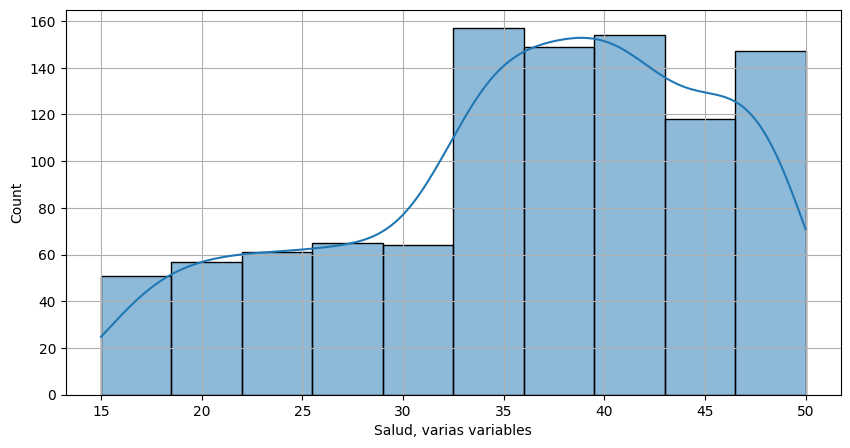

El número de datos por intervalo es:
[ 51  57  61  65  64 157 149 154 118 147]
Los intervalos inferiores:
[15.003 18.502 22.001 25.5   28.999 32.498 35.997 39.496 42.995 46.494]
Los intervalos superiores:
[18.502 22.001 25.5   28.999 32.498 35.997 39.496 42.995 46.494 49.993]
La media de los datos integrados es: 36.09105913978495
La media de los datos observados es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La discrepancia entre las medias es: 9.480224662987935


In [46]:
##Método aceptación y rechazo entre Sabaneta y Envigado

BMIint2=np.copy(np.array(BMI))

for k in range(len(BMI3)):
  print(BMI3[k])

  VPo = np.exp(-0.5*((us-BMI3[k])/sigmas)**2) #Que tanto se parece el dato de los internos
  VPe= np.exp(-0.5*((ue-BMI3[k])/sigmas)**2) #Que tan represnetativo es un dato externo

  if VPo>VPe:
    BMIint2=np.append(BMIint2,BMI3[k])
    print(f"El dato integrado es {k}")

ui2,sigmai2,Casi2,Kuri2,dfi2=caracterizacion(BMIint2)
print("La media de los datos integrados es:",ui2)
print("La media de los datos observados es:",us)
print("La media de los datos externos es:",ub)

duoui2=np.abs((us-ui2)/us)*100  #Discrepacia delos datos observados y los integrados
print("La discrepancia entre las medias es:",duoui2)

#**Integración entre Sabaneta e Itaguí**


In [47]:
BMIint=np.copy(np.array(BMI))   #Variable de Integración
BMI4=np.array(BMI4)

m1=0
for k in range(len(BMI4)):
  VP=np.exp(-0.5*((us-BMI4[k,])/sigmas)**2)

  if VP>0.9:
      m1=m1+1   #Contador de cuantos datos integrados
      BMIint=np.append(BMIint,BMI4[k])
      print("El dato a integrar es:",BMI4[k])

print("Los datos integrados son:",m1)

El dato a integrar es: 34.553
El dato a integrar es: 33.849
El dato a integrar es: 29.793
El dato a integrar es: 36.061
El dato a integrar es: 30.389
El dato a integrar es: 36.099
El dato a integrar es: 29.835
El dato a integrar es: 35.745
El dato a integrar es: 30.686
El dato a integrar es: 33.105
El dato a integrar es: 32.894
El dato a integrar es: 33.104
El dato a integrar es: 30.563
El dato a integrar es: 33.985
El dato a integrar es: 30.262
El dato a integrar es: 34.574
El dato a integrar es: 33.256
El dato a integrar es: 36.043
El dato a integrar es: 30.755
El dato a integrar es: 33.372
El dato a integrar es: 35.562
El dato a integrar es: 30.391
El dato a integrar es: 37.269
El dato a integrar es: 31.797
El dato a integrar es: 34.344
El dato a integrar es: 28.841
El dato a integrar es: 36.201
El dato a integrar es: 33.069
El dato a integrar es: 33.057
El dato a integrar es: 29.387
El dato a integrar es: 37.221
El dato a integrar es: 31.418
El dato a integrar es: 34.445
El dato a 

25.563
49.786
El dato integrado es 1
49.004
El dato integrado es 2
47.335
El dato integrado es 3
34.553
El dato integrado es 4
33.849
El dato integrado es 5
28.181
39.515
El dato integrado es 7
22.048
29.793
44.89
El dato integrado es 10
46.988
El dato integrado es 11
18.118
18.572
47.433
El dato integrado es 14
22.988
21.106
24.209
36.061
El dato integrado es 18
46.955
El dato integrado es 19
39.968
El dato integrado es 20
47.946
El dato integrado es 21
30.389
22.341
28.344
36.099
El dato integrado es 25
21.069
15.71
41.289
El dato integrado es 28
29.835
35.745
El dato integrado es 30
39.514
El dato integrado es 31
39.945
El dato integrado es 32
30.686
27.725
49.371
El dato integrado es 35
18.16
22.737
33.105
El dato integrado es 38
32.894
El dato integrado es 39
41.255
El dato integrado es 40
33.104
El dato integrado es 41
16.506
45.917
El dato integrado es 43
30.563
27.063
48.767
El dato integrado es 46
19.77
33.985
El dato integrado es 48
39.35
El dato integrado es 49
30.262
23.361

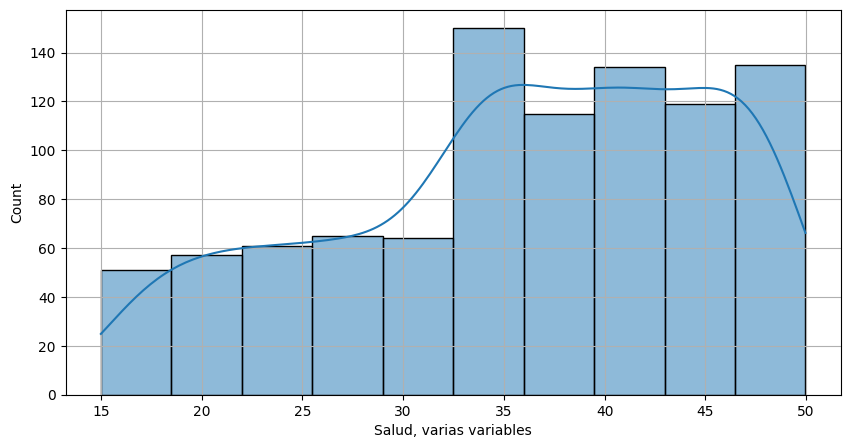

El número de datos por intervalo es:
[ 51  57  61  65  64 150 115 134 119 135]
Los intervalos inferiores:
[15.003  18.4992 21.9954 25.4916 28.9878 32.484  35.9802 39.4764 42.9726
 46.4688]
Los intervalos superiores:
[18.4992 21.9954 25.4916 28.9878 32.484  35.9802 39.4764 42.9726 46.4688
 49.965 ]
La media de los datos integrados es: 35.77616309148265
La media de los datos observados es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La discrepancia entre las medias es: 8.52500497879696


In [48]:
##Método aceptación y rechazo entre Sabaneta e Itaguí

BMIint2=np.copy(np.array(BMI))

for k in range(len(BMI4)):
  print(BMI4[k])

  VPo = np.exp(-0.5*((us-BMI4[k])/sigmas)**2) #Que tanto se parece el dato de los internos
  VPe= np.exp(-0.5*((ue-BMI4[k])/sigmas)**2) #Que tan represnetativo es un dato externo

  if VPo>VPe:
    BMIint2=np.append(BMIint2,BMI4[k])
    print(f"El dato integrado es {k}")

ui2,sigmai2,Casi2,Kuri2,dfi2=caracterizacion(BMIint2)
print("La media de los datos integrados es:",ui2)
print("La media de los datos observados es:",us)
print("La media de los datos externos es:",ub)

duoui2=np.abs((us-ui2)/us)*100  #Discrepacia delos datos observados y los integrados
print("La discrepancia entre las medias es:",duoui2)

#**Integración Sabaneta con Caldas**

In [49]:
BMIint=np.copy(np.array(BMI))   #Variable de Integración
BMI5=np.array(BMI5)

m1=0
for k in range(len(BMI5)):
  VP=np.exp(-0.5*((us-BMI5[k,])/sigmas)**2)

  if VP>0.9:
      m1=m1+1   #Contador de cuantos datos integrados
      BMIint=np.append(BMIint,BMI5[k])
      print("El dato a integrar es:",BMI5[k])

print("Los datos integrados son:",m1)

El dato a integrar es: 29.526
El dato a integrar es: 33.307
El dato a integrar es: 29.501
El dato a integrar es: 31.665
El dato a integrar es: 36.313
El dato a integrar es: 31.477
El dato a integrar es: 35.036
El dato a integrar es: 31.922
El dato a integrar es: 33.959
El dato a integrar es: 37.345
El dato a integrar es: 30.963
El dato a integrar es: 35.509
El dato a integrar es: 35.313
El dato a integrar es: 32.806
El dato a integrar es: 34.688
El dato a integrar es: 34.597
El dato a integrar es: 32.341
El dato a integrar es: 34.082
El dato a integrar es: 28.77
El dato a integrar es: 36.796
El dato a integrar es: 36.286
El dato a integrar es: 36.779
El dato a integrar es: 30.306
El dato a integrar es: 31.35
El dato a integrar es: 29.119
El dato a integrar es: 31.793
El dato a integrar es: 30.352
El dato a integrar es: 35.762
El dato a integrar es: 36.646
El dato a integrar es: 28.778
El dato a integrar es: 29.518
El dato a integrar es: 35.921
El dato a integrar es: 29.687
El dato a in

29.526
15.3
33.307
El dato integrado es 2
38.052
El dato integrado es 3
29.501
31.665
27.748
36.313
El dato integrado es 7
18.959
24.597
31.477
35.036
El dato integrado es 11
42.262
El dato integrado es 12
47.788
El dato integrado es 13
25.113
15.975
16.298
31.922
28.349
38.409
El dato integrado es 19
47.071
El dato integrado es 20
17.792
33.959
El dato integrado es 22
37.345
El dato integrado es 23
43.403
El dato integrado es 24
47.542
El dato integrado es 25
46.516
El dato integrado es 26
39.077
El dato integrado es 27
17.216
46.382
El dato integrado es 29
30.963
49.44
El dato integrado es 31
35.509
El dato integrado es 32
35.313
El dato integrado es 33
26.099
20.647
32.806
El dato integrado es 36
43.794
El dato integrado es 37
34.688
El dato integrado es 38
43.388
El dato integrado es 39
15.886
22.359
46.022
El dato integrado es 42
15.0
34.597
El dato integrado es 44
49.985
El dato integrado es 45
32.341
26.581
34.082
El dato integrado es 48
47.307
El dato integrado es 49
46.054
El 

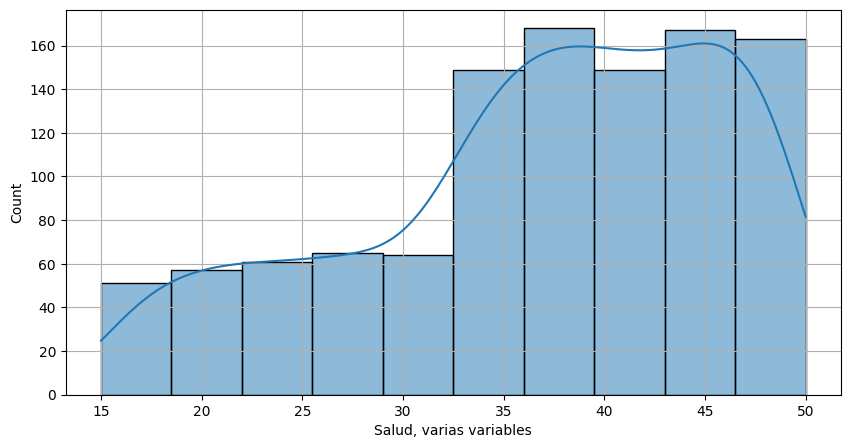

El número de datos por intervalo es:
[ 51  57  61  65  64 149 168 149 167 163]
Los intervalos inferiores:
[15.003  18.5012 21.9994 25.4976 28.9958 32.494  35.9922 39.4904 42.9886
 46.4868]
Los intervalos superiores:
[18.5012 21.9994 25.4976 28.9958 32.494  35.9922 39.4904 42.9886 46.4868
 49.985 ]
La media de los datos integrados es: 36.67009616087751
La media de los datos observados es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La discrepancia entre las medias es: 11.23670132696922


In [50]:
##Método aceptación y rechazo entre Sabaneta y Caldas

BMIint2=np.copy(np.array(BMI))

for k in range(len(BMI5)):
  print(BMI5[k])

  VPo = np.exp(-0.5*((us-BMI5[k])/sigmas)**2) #Que tanto se parece el dato de los internos
  VPe= np.exp(-0.5*((ue-BMI5[k])/sigmas)**2) #Que tan represnetativo es un dato externo

  if VPo>VPe:
    BMIint2=np.append(BMIint2,BMI5[k])
    print(f"El dato integrado es {k}")

ui2,sigmai2,Casi2,Kuri2,dfi2=caracterizacion(BMIint2)
print("La media de los datos integrados es:",ui2)
print("La media de los datos observados es:",us)
print("La media de los datos externos es:",ub)

duoui2=np.abs((us-ui2)/us)*100  #Discrepacia delos datos observados y los integrados
print("La discrepancia entre las medias es:",duoui2)

#**Analisis final**

Al realizar la integración de los datos a cada sede, se identifica que por parte de la sede de Medellín, se pueden integrar 237 personas, es decir que es el lugar que más gente puede pasar de sabaneta a Medellín, aunque la sede de Caldas no se queda atras y podría recibir a 226 personas, esto quiere decir que son las sedes que más personas pueden recibir,sin embargo hay unas sedes que no alcanzana integrar tantas personas como las anteriores mencionadas, por diferentes aspectos, además se puede evidenciar que la suma de los datos integrados para todas las sedes da más de 1.000 perdonas, esto quiere decir que hay valores que pueden ser recibidos en una o más sedes